# First look into TiRex

In [1]:
import sys
sys.path.append('../tirex/src') # Add the path to the tirex module

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch

from tirex import ForecastModel, load_model
from tirex.util import plot_forecast

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)

# Load data

Download the data from the notebook [data_download.ipynb](data_download.ipynb) before.

In [3]:
data_path_train = "../data/train.csv"
data_path_test = "../data/test.csv"
data_test = pl.read_csv(data_path_test, try_parse_dates=True)

number_series = len(data_test['series_index'].unique())
print(f"Number of time series in the test set: {number_series}")
data_test.head()

Number of time series in the test set: 361


timestamp,value,series_name,series_index
datetime[μs],f64,str,i64
2025-09-27 22:00:00,0.564,"""home_electricity""",0
2025-09-27 22:15:00,0.564,"""home_electricity""",0
2025-09-27 22:30:00,0.556,"""home_electricity""",0
2025-09-27 22:45:00,0.568,"""home_electricity""",0
2025-09-27 23:00:00,0.56,"""home_electricity""",0


# Load Model

In [4]:
model: ForecastModel = load_model("NX-AI/TiRex")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 35,291,200


# Prediction

Selected time series HU_solar_generation_actual_15 with index 50 and shape (7172,)


<Axes: >

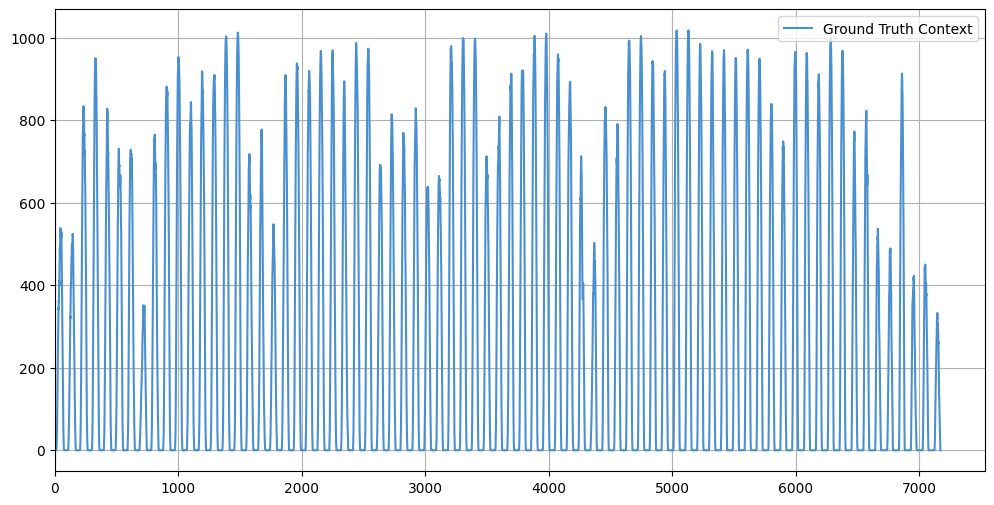

In [5]:
# select a single time series from the test data
idx_s = 50

df_s = data_test.filter(pl.col("series_index") == idx_s)
name_s = df_s.select(pl.col("series_name"))[0].item()
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1) # copy to make it writeable for the model
print(f"Selected time series {name_s} with index {idx_s} and shape {values_s.shape}")
plot_forecast(values_s)

In [15]:
# set prediction length and starting point for prediction
prediction_length = 2200
start_point = -1500

ctx_s, future_s = np.split(values_s, [start_point])
ctx_s.shape, future_s.shape

((5672,), (1500,))

In [11]:
# test batch input
ctx_s_batch = np.stack([ctx_s, ctx_s], axis=0)

In [16]:
quantiles, mean = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)

<Axes: >

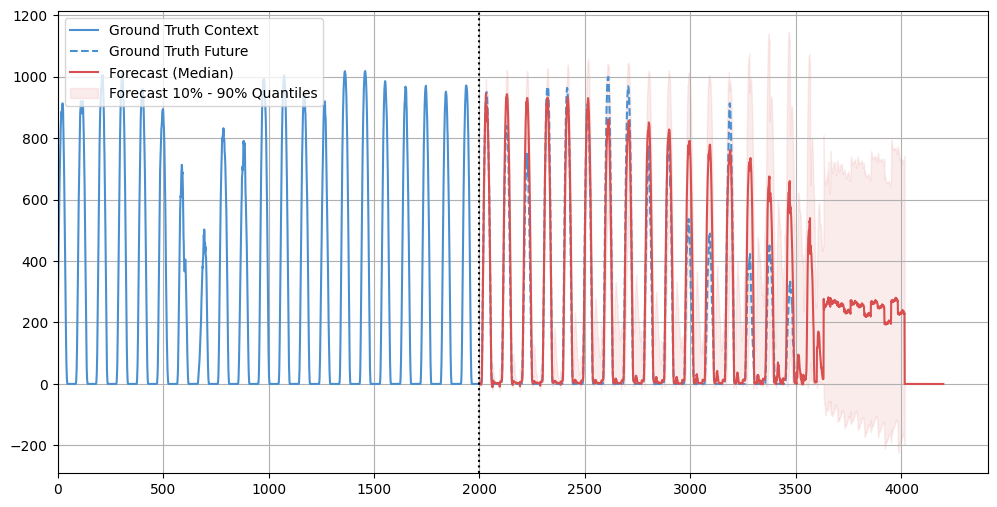

In [75]:
cap_input = -2000
plot_forecast(ctx_s[cap_input:], quantiles.numpy()[0], future_s)